Notebook for producing the paper plots.

In [352]:
import pandas as pd
import numpy as np
import pickle
import obspy
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from seismicif.datamod.loading_utils import find_paths, find_date_in_strings
from seismicif.datamod.preproc_utils import preproc_stream
from datetime import timedelta
from seismicif.isolation_forest import create_if_stream
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.dates as mdates
import matplotlib.ticker as mticker


plt.rcParams["font.family"] = "sans-serif"

### Rock Avalanche

In [157]:
nuug_paths = find_paths("DK", "NUUG", "HHZ.D", start=2017, stop=2017)
ra_paths = [
    find_date_in_strings(nuug_paths, "2017-06-17")[0],
    find_date_in_strings(nuug_paths, "2017-06-18")[0],
]

scores_df = pd.read_csv(f"../output/DK/if/scores/NUUG.csv", index_col=0)
scores_df["start"] = [obspy.UTCDateTime(str(i)) for i in scores_df["start"]]
scores_df["stop"] = [obspy.UTCDateTime(str(i)) for i in scores_df["stop"]]

if_st = create_if_stream(scores_df, station="NUUG", sr=0.02, network="DK")


ra_tr = obspy.Trace()
st1 = obspy.read(ra_paths[0])
preproc_stream(st1)
st2 = obspy.read(ra_paths[1])
preproc_stream(st2)
st2.trim(
    starttime=st[0].stats.starttime + timedelta(seconds=0.01),
    endtime=st[0].stats.endtime,
)
ra_tr.data = np.concatenate((st1[0].data, st2[0].data))
ra_tr.stats.starttime = st1[0].stats.starttime
ra_tr.stats.sampling_rate = st1[0].stats.sampling_rate

t0 = obspy.UTCDateTime("2017-06-17T23:30:00.000000Z")
t1 = obspy.UTCDateTime("2017-06-18T00:30:00.000000Z")

ra_tr.trim(t0, t1)
if_tr = if_st.copy().trim(t0, t1)[0]

trigger_on = obspy.UTCDateTime("2017-06-17T23:39:11.680001Z") - t0
trigger_off = obspy.UTCDateTime("2017-06-18T00:17:31.680001Z") - t0

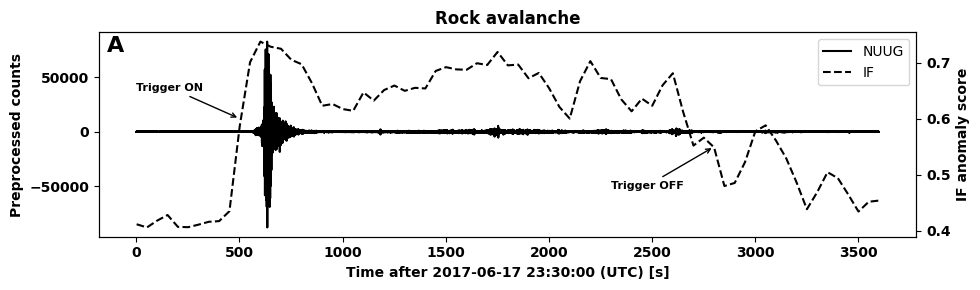

In [172]:
# waveform
npts1 = ra_tr.stats.npts
dt1 = 1 / ra_tr.stats.sampling_rate
start_offset = ra_tr.stats.starttime - t0
t1 = np.arange(0, npts1) * dt1 + +start_offset

npts2 = if_tr.stats.npts
dt2 = 1 / if_tr.stats.sampling_rate
start_offset = if_tr.stats.starttime - t0
t2 = np.arange(0, npts2) * dt2 + start_offset

fig, ax1 = plt.subplots(figsize=(10, 3))
ax1.plot(t1, tr1.data, color="black", label="NUUG")
ax1.set_xlabel(
    f"Time after {t0.strftime('%Y-%m-%d %H:%M:%S')} (UTC) [s]", fontweight="bold"
)
ax1.set_ylabel("Preprocessed counts", color="black", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="black")

ax2 = ax1.twinx()
ax2.plot(t2, if_tr.data, color="black", label="IF", linestyle="--")
ax2.set_ylabel("IF anomaly score", color="black", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="black")

ax1.set_ylabel("Preprocessed counts")

for label in ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels():
    label.set_fontweight("bold")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()


ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")
ax1.text(
    0.01,
    0.98,
    "A",
    transform=ax1.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="left",
)


plt.annotate(
    "Trigger ON",
    xy=(trigger_on - 50, 0.6),
    xytext=(0, 0.65),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=8,
    fontweight="bold",
)

plt.annotate(
    "Trigger OFF",
    xy=(trigger_off - 50, 0.55),
    xytext=(2300, 0.475),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=8,
    fontweight="bold",
)

plt.title("Rock avalanche", fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/fig02.pdf", dpi=300)
plt.show()

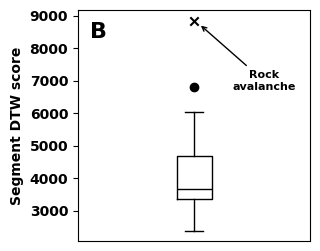

In [219]:
# dendrogram boxplot
with open(f"../output/DK/dtw/info/NUUG.pkl", "rb") as f:
    info = pickle.load(f)

indices = info[0]
d = np.array([np.median(i[0]) for i in info[1]])

D = np.zeros([50, 50])

for n in range(len(indices)):
    i, j = indices[n]

    D[i, j] = d[n]

D = D + D.T

condensed_D = squareform(D)
linkage_matrix = sch.linkage(condensed_D, method="complete")

hh = []

for i in range(linkage_matrix.shape[0]):
    if linkage_matrix[i, 0] < 50 or linkage_matrix[i, 1] < 50:
        hh.append(linkage_matrix[i, 2])

hh = np.array(hh)

fig, ax = plt.subplots(figsize=(3, 3))
box = ax.boxplot(hh, patch_artist=False, flierprops=dict(marker=""))

IQR = np.quantile(hh, 0.75) - np.quantile(hh, 0.25)
up = np.quantile(hh, 0.75) + 1.5 * IQR

outliers = np.sort(hh[hh > up])

for i in range(outliers.shape[0] - 1):
    plt.scatter(1, outliers[i], c="k", marker="o")

plt.scatter(1, outliers[-1], c="k", marker="x")

ax.text(
    0.05,
    0.95,
    "B",
    transform=ax.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="left",
)

ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(axis="x", bottom=False)

for element in ["boxes", "whiskers", "caps", "medians"]:
    plt.setp(box[element], color="black")

plt.ylabel("Segment DTW score", fontweight="bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

plt.annotate(
    "Rock\navalanche",
    xy=(1.02, outliers[-1] - 100),
    xytext=(1.3, 7000),
    ha="center",
    va="center",
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=8,
    fontweight="bold",
)

# plt.tight_layout()
plt.savefig(
    "../plots/fig03.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
    pad_inches=0.1,
)
plt.show()

### KARAT Dendrogram

In [226]:
with open(f"../output/DK/dtw/info/KARAT.pkl", "rb") as f:
    info = pickle.load(f)

karat_dtc = pd.read_csv("../catalogs/DK/KARAT.csv")

indices = info[0]
d = np.array([np.median(i[0]) for i in info[1]])

D = np.zeros([50, 50])

for n in range(len(indices)):
    i, j = indices[n]

    D[i, j] = d[n]

D = D + D.T

condensed_D = squareform(D)
linkage_matrix = sch.linkage(condensed_D, method="complete")

In [273]:
from matplotlib.lines import Line2D

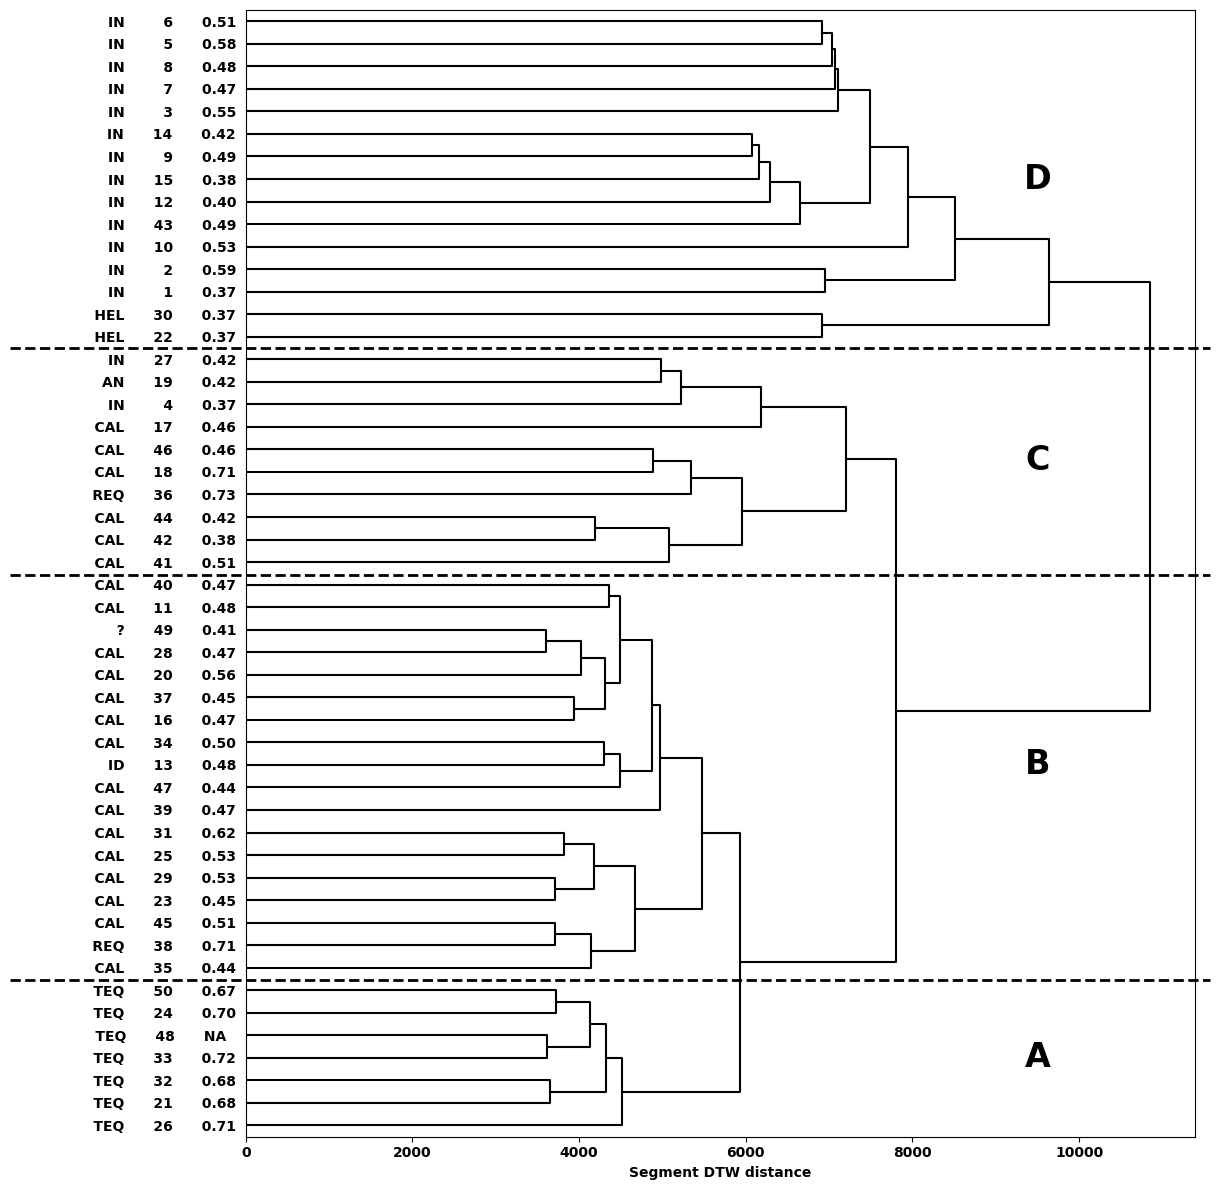

In [305]:
value_width = 6
name_width = 10
index_width = 4
spacer = "\u2007"

labels = []
for i in range(karat_dtc.shape[0]):
    name = str(karat_dtc["labels"][i]).rjust(name_width)
    index = str(i + 1).rjust(index_width)

    value = karat_dtc.iloc[i, 3]
    if pd.isna(value):
        value_str = " NA ".rjust(value_width - 1)
    else:
        value_str = f"{value:.2f}".rjust(value_width)

    name = name.replace(" ", spacer)
    index = index.replace(" ", spacer)
    value_str = value_str.replace(" ", spacer)

    label = f"{name}  {index}  {value_str}"
    labels.append(label)

fig = plt.figure(figsize=(12, 12))
dendro = sch.dendrogram(
    linkage_matrix,
    labels=labels,
    orientation="right",
    link_color_func=lambda k: "black",
)

for label in plt.gca().get_yticklabels():
    label.set_fontfamily("sans-serif")
    label.set_fontweight("bold")
    label.set_fontsize(10)

for label in plt.gca().get_xticklabels():
    label.set_fontweight("bold")

plt.xlabel("Segment DTW distance", fontweight="bold")
ymin, ymax = plt.gca().get_ylim()

plt.text(
    x=9500,
    y=425,
    s="D",
    horizontalalignment="center",
    verticalalignment="center",
    fontweight="bold",
    fontsize=24,
)
plt.text(
    x=9500,
    y=300,
    s="C",
    horizontalalignment="center",
    verticalalignment="center",
    fontweight="bold",
    fontsize=24,
)
plt.text(
    x=9500,
    y=165,
    s="B",
    horizontalalignment="center",
    verticalalignment="center",
    fontweight="bold",
    fontsize=24,
)
plt.text(
    x=9500,
    y=35,
    s="A",
    horizontalalignment="center",
    verticalalignment="center",
    fontweight="bold",
    fontsize=24,
)
# y_fig_coord = ax.transData.transform((0, 350))[1]

for y_fig_coord in [215, 620, 847.5]:
    y_fig_frac = y_fig_coord / fig.bbox.height

    # Draw line at that height in figure space
    line = Line2D(
        [0, 1],
        [y_fig_frac, y_fig_frac],
        transform=fig.transFigure,
        color="k",
        linestyle="--",
        linewidth=2,
    )
    fig.add_artist(line)

plt.tight_layout()
plt.savefig("../plots/fig04.pdf")
plt.show()

In [ ]:
# amplitude plot
karat_paths = find_paths("DK", "KARAT", "HHZ.D", start=2022, stop=2023)

In [ ]:
median_amplitudes = []
times = []

for p in karat_paths:
    st = obspy.read(p)
    preproc_stream(st)

    data = []

    for tr in st:
        data.append(tr.data)

    median_amplitudes.append(np.median(np.abs(np.concatenate(data))))

    year = st[0].stats.starttime.year
    month = st[0].stats.starttime.month
    day = st[0].stats.starttime.day
    times.append(pd.Timestamp(year=year, month=month, day=day))

    # print(times[-1],median_amplitudes[-1])

amplitide_df = pd.DataFrame({"times": times, "amplitudes": median_amplitudes})

scores_df = pd.read_csv(f"../output/DK/if/scores/KARAT.csv", index_col=0)
scores_df["start"] = [obspy.UTCDateTime(str(i)) for i in scores_df["start"]]
scores_df["stop"] = [obspy.UTCDateTime(str(i)) for i in scores_df["stop"]]
karat_if_st = create_if_stream(scores_df, station="KARAT", sr=0.02, network="DK")

2022-05-30 00:00:00 5275.997364103325
2022-05-31 00:00:00 1236.8649226567522
2022-06-03 00:00:00 3212.6555434864367
2022-06-11 00:00:00 411.02760469623456
2022-06-12 00:00:00 441.155804765071
2022-06-13 00:00:00 557.8480793681078
2022-06-14 00:00:00 449.2162233737763
2022-06-15 00:00:00 210.03355607945434
2022-06-16 00:00:00 181.1800942181004
2022-08-15 00:00:00 38.24685352928278
2022-08-16 00:00:00 32.81647866020248
2022-08-17 00:00:00 18.957138305390274
2022-08-18 00:00:00 15.906187338625715
2022-08-19 00:00:00 17.577020277494547
2022-08-20 00:00:00 17.046915782281395
2022-08-21 00:00:00 16.645113469339172
2022-08-22 00:00:00 52.70025436747578
2022-08-23 00:00:00 49.1640193157034
2022-08-24 00:00:00 53.33496148668124
2022-08-25 00:00:00 30.150985138043353
2022-08-26 00:00:00 26.35720054369049
2022-08-27 00:00:00 19.235133804913048
2022-08-28 00:00:00 17.575907773720672
2022-08-29 00:00:00 30.72902531663746
2022-08-30 00:00:00 47.67454161785585
2022-08-31 00:00:00 32.87833727253094
20

c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)


2022-09-17 00:00:00 31.462837239451908
2022-09-18 00:00:00 35.82678237101231
2022-09-19 00:00:00 27.03707236384334
2022-09-20 00:00:00 16.891480238404466
2022-09-21 00:00:00 19.256767630742935
2022-09-22 00:00:00 22.639288037046732
2022-09-23 00:00:00 26.64290516443097
2022-09-24 00:00:00 34.57162421034748
2022-09-25 00:00:00 66.79292290416453
2022-09-26 00:00:00 30.051380662725485
2022-09-27 00:00:00 19.288513510165004
2022-09-28 00:00:00 19.86105291073966
2022-09-29 00:00:00 31.015936284571755
2022-09-30 00:00:00 31.520900700130184
2022-10-01 00:00:00 40.67103837145769
2022-10-02 00:00:00 38.448353382951844
2022-10-03 00:00:00 29.543654241538007
2022-10-04 00:00:00 18.264370860660097
2022-10-05 00:00:00 27.018817441373955
2022-10-06 00:00:00 40.46010742732311
2022-10-07 00:00:00 37.57526580556781
2022-10-08 00:00:00 28.636470579973548
2022-10-09 00:00:00 31.315288765620352
2022-10-10 00:00:00 32.0597727296217
2022-10-11 00:00:00 28.256736224078413
2022-10-12 00:00:00 39.2931151340706

C:\Users\franc\AppData\Local\Temp\ipykernel_53756\2048165448.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


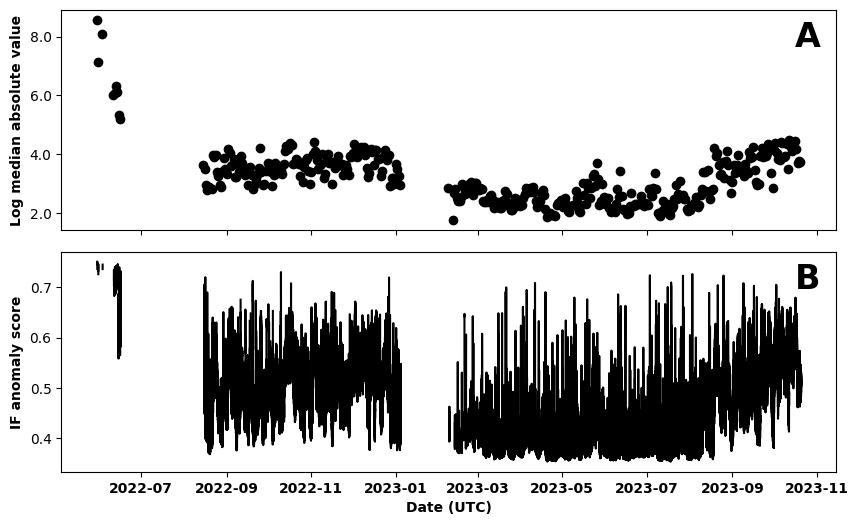

In [353]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 6), gridspec_kw={"hspace": 0.1}
)

ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax1.scatter(amplitide_df["times"], np.log(amplitide_df["amplitudes"]), c="k")
ax1.set_ylabel("Log median absolute value", fontweight="bold")

ax1.text(
    0.98,
    0.95,
    "A",
    transform=ax1.transAxes,
    fontsize=24,
    fontweight="bold",
    va="top",
    ha="right",
)

for tr in karat_if_st:
    t = np.array(
        [tr.stats.starttime + i / tr.stats.sampling_rate for i in range(tr.stats.npts)]
    )
    t = np.array([ti.datetime for ti in t])
    ax2.plot(t, tr.data, color="black")

ax2.set_xlabel("Date (UTC)", fontweight="bold")
ax2.set_ylabel("IF anomaly score", fontweight="bold")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

for label in ax2.get_xticklabels():
    label.set_fontweight("bold")

ax2.text(
    0.98,
    0.95,
    "B",
    transform=ax2.transAxes,
    fontsize=24,
    fontweight="bold",
    va="top",
    ha="right",
)

fig.tight_layout()
plt.savefig("../plots/fig05.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

### Appendix A

In [ ]:
# for stat in stations:
#     scores_df = pd.read_csv("../IF_SCORES/" + stat + ".csv",index_col=0)
#     scores_df = scores_df.iloc[:np.max(np.where(["2018" in i for i in scores_df["start"]])[0]),:]

#     scores_df["start"] = [obspy.UTCDateTime(i) for i in scores_df["start"]]
#     scores_df["stop"] = [obspy.UTCDateTime(i) for i in scores_df["stop"]]

#     high_conf_flows = gt_dict[stat]["tr_gt"]
#     high_conf_flows = high_conf_flows.iloc[np.where(["2018" in str(i) for i in high_conf_flows["start"]])[0],:]

#     psymb = np.zeros(scores_df.shape[0])

#     for j in range(high_conf_flows.shape[0]):
#             t0_gt = high_conf_flows.iloc[j,0]
#             t1_gt = high_conf_flows.iloc[j,1]

#             for i in range(scores_df.shape[0]):
#                 t0 = scores_df.iloc[i,0]
#                 t1 = scores_df.iloc[i,1]

#                 if t1 >= t0_gt:
#                     break

#             hold = i

#             for i in range(hold,scores_df.shape[0]):
#                 t0 = scores_df.iloc[i,0]
#                 t1 = scores_df.iloc[i,1]

#                 if t0 > t1_gt:
#                     break

#             psymb[hold:i] = 1


#     plt.scatter(np.log(scores_df["std"][psymb == 0]), scores_df["anomaly_score"][psymb == 0],
#                 marker="o", edgecolors="gray", facecolors="none")
#     plt.scatter(np.log(scores_df["std"][psymb == 1]), scores_df["anomaly_score"][psymb == 1],
#                 marker="x", color="black")

#     plt.title(stat)
#     plt.xlabel("Log Standard Deviation")
#     plt.ylabel("IF Anomaly Score")
#     plt.savefig(stat + "_scores.png",bbox_inches="tight")
# plt.show()

### Appendix D

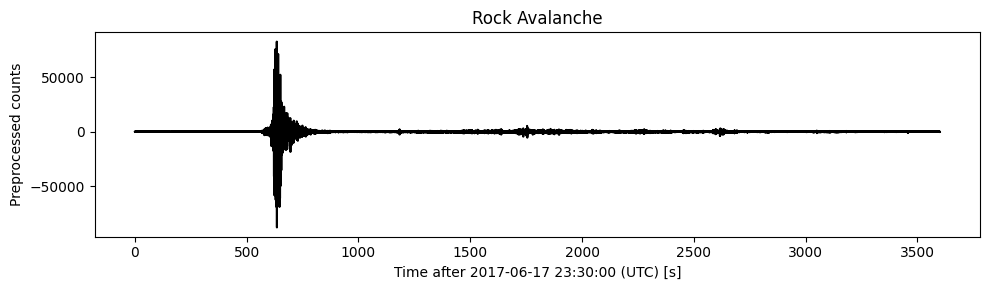

In [ ]:
# npts = ra_st.stats.npts
# sampling_rate = ra_st.stats.sampling_rate
# t = np.arange(0, npts) / sampling_rate  # time in seconds after start time

# # Plot the trace
# plt.figure(figsize=(10, 3))
# plt.plot(t, ra_st.data, color='black')
# plt.xlabel(f"Time after {ra_st.stats.starttime.strftime('%Y-%m-%d %H:%M:%S')} (UTC) [s]")
# plt.ylabel("Preprocessed counts")
# plt.title("Rock Avalanche")
# plt.tight_layout()
# plt.show()